## Predict Diamond Price using different ML model

Diamonds are valued based on several characteristics such as carat weight, cut quality, color, clarity, and physical dimensions. Understanding how these factors influence price can help build predictive models for estimating diamond value.

In this project, we analyze the Diamonds dataset to identify the most important factors affecting diamond price and build machine learning models to predict it.

#### Import necessary module

In [1]:
import tensorflow

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_squared_error

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

#### Read/Load the data

In [3]:
diamond = pd.read_csv("gemstone.csv")
diamond.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [4]:
diamond.shape

(193573, 11)

The dataset contains 53,940 observations and 10 variables, including both numeric and categorical features describing diamond characteristics.

Key features:

Feature	Description:

1. carat -	weight of diamond
2. cut	   -   quality of cut
3. color -	diamond color grade
4. clarity -	measurement of diamond purity
5. depth - 	total depth percentage
6. table -	width of top relative to widest point
7. x,y,z -	physical dimensions
8. price -	target variable

#### EDA

In [5]:
diamond.info()
diamond.describe()

<class 'pandas.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  str    
 3   color    193573 non-null  str    
 4   clarity  193573 non-null  str    
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), str(3)
memory usage: 16.2 MB


,id,carat,depth,table,x,y,z,price
count,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000
mean,96786.000000,0.790688,61.820574,57.227675,5.715312,5.720094,3.534246,3969.155414
std,55879.856166,0.462688,1.081704,1.918844,1.109422,1.102333,0.688922,4034.374138
min,0.000000,0.200000,52.100000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,48393.000000,0.400000,61.300000,56.000000,4.700000,4.710000,2.900000,951.000000
50%,96786.000000,0.700000,61.900000,57.000000,5.700000,5.720000,3.530000,2401.000000
75%,145179.000000,1.030000,62.400000,58.000000,6.510000,6.510000,4.030000,5408.000000
max,193572.000000,3.500000,71.600000,79.000000,9.650000,10.010000,31.300000,18818.000000


#### Missing Values Check

In [6]:
diamond.isnull().sum()

id         0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

#### Target Variable Distribution (Price)

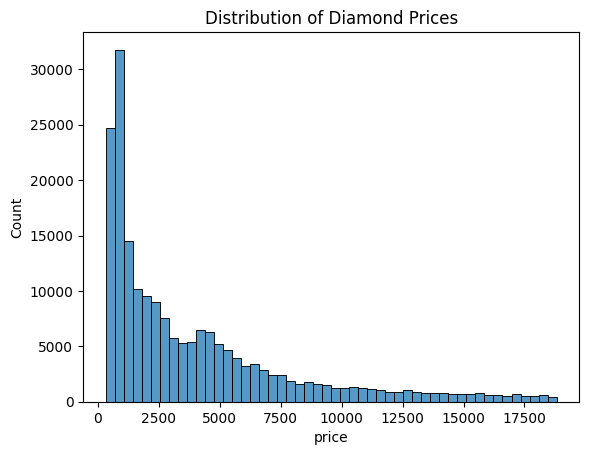

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(diamond['price'], bins=50)
plt.title("Distribution of Diamond Prices")
plt.show()

The diamond price distribution is heavily right-skewed, indicating that most diamonds are affordable while a small number have extremely high prices.

#### Price vs Carat (Most Important Relationship)

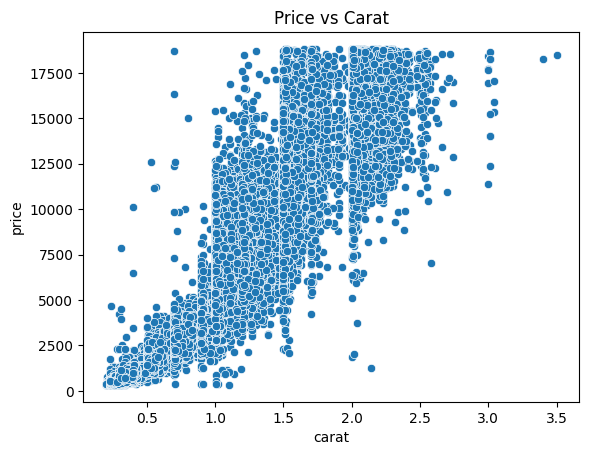

In [8]:
sns.scatterplot(x="carat", y="price", data=diamond)
plt.title("Price vs Carat")
plt.show()

#### Expected pattern:

Strong positive relationship

Price increases rapidly with carat

Story:

Larger diamonds (higher carat weight) tend to have significantly higher prices.

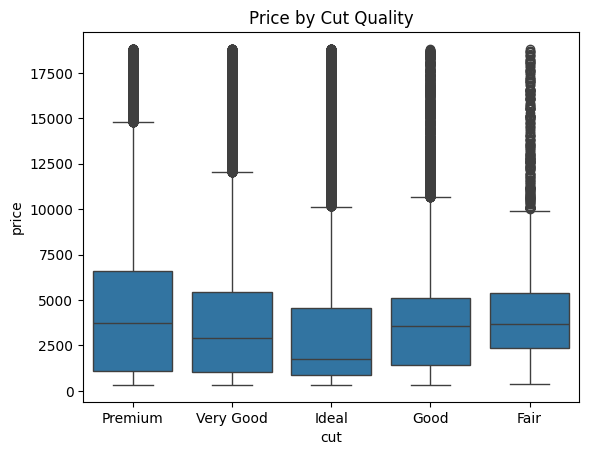

In [9]:
sns.boxplot(x="cut", y="price", data=diamond)
plt.title("Price by Cut Quality")
plt.show()


#### Possible insight:

Premium / Ideal cuts may show higher prices

But carat still dominates price

Story:

Better cut quality tends to increase price, although the relationship is not as strong as carat weight.

#### Price vs Color

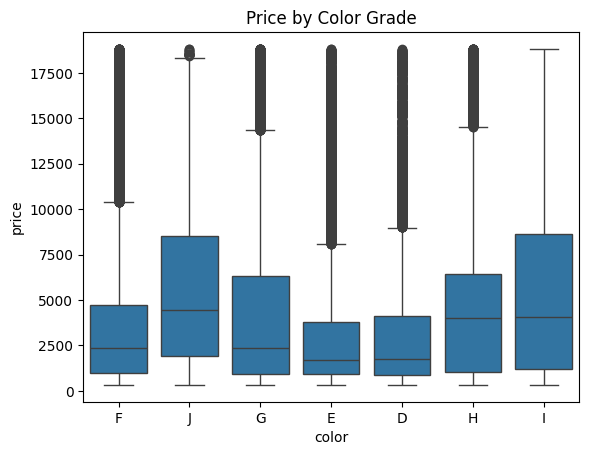

In [10]:
sns.boxplot(x="color", y="price", data=diamond)
plt.title("Price by Color Grade")
plt.show()

Diamonds with better color grades tend to command higher prices.

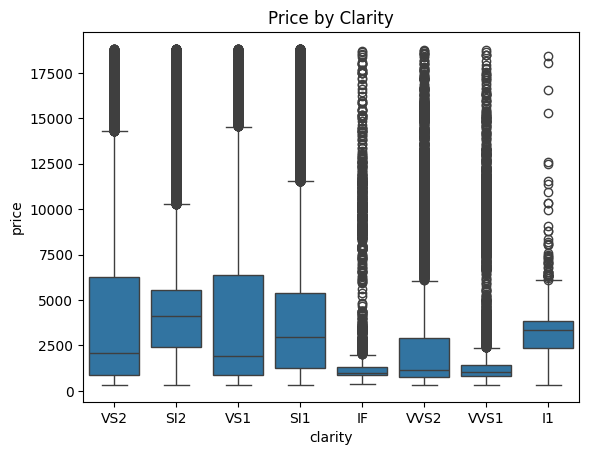

In [11]:
# Price vs Clarity
sns.boxplot(x="clarity", y="price", data=diamond)
plt.title("Price by Clarity")
plt.show()

Diamonds with higher clarity grades generally have higher prices due to fewer internal imperfections.

#### Correlation Matrix

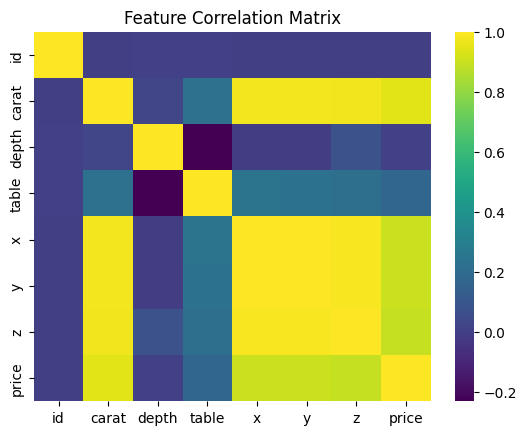

In [51]:
corr = diamond.corr(numeric_only=True)

sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Feature Correlation Matrix")
plt.show()

The strong correlation between carat and the dimensions (x, y, z) suggests that these variables all represent diamond size.

#### Detect Outliers

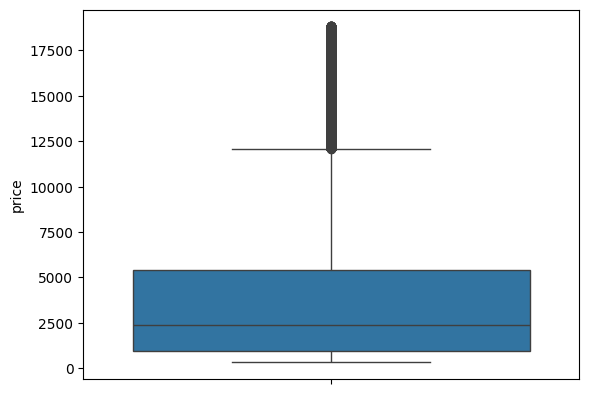

In [13]:
sns.boxplot(diamond["price"])
plt.show()

Some diamonds have extremely high price

Outliers may affect regression models

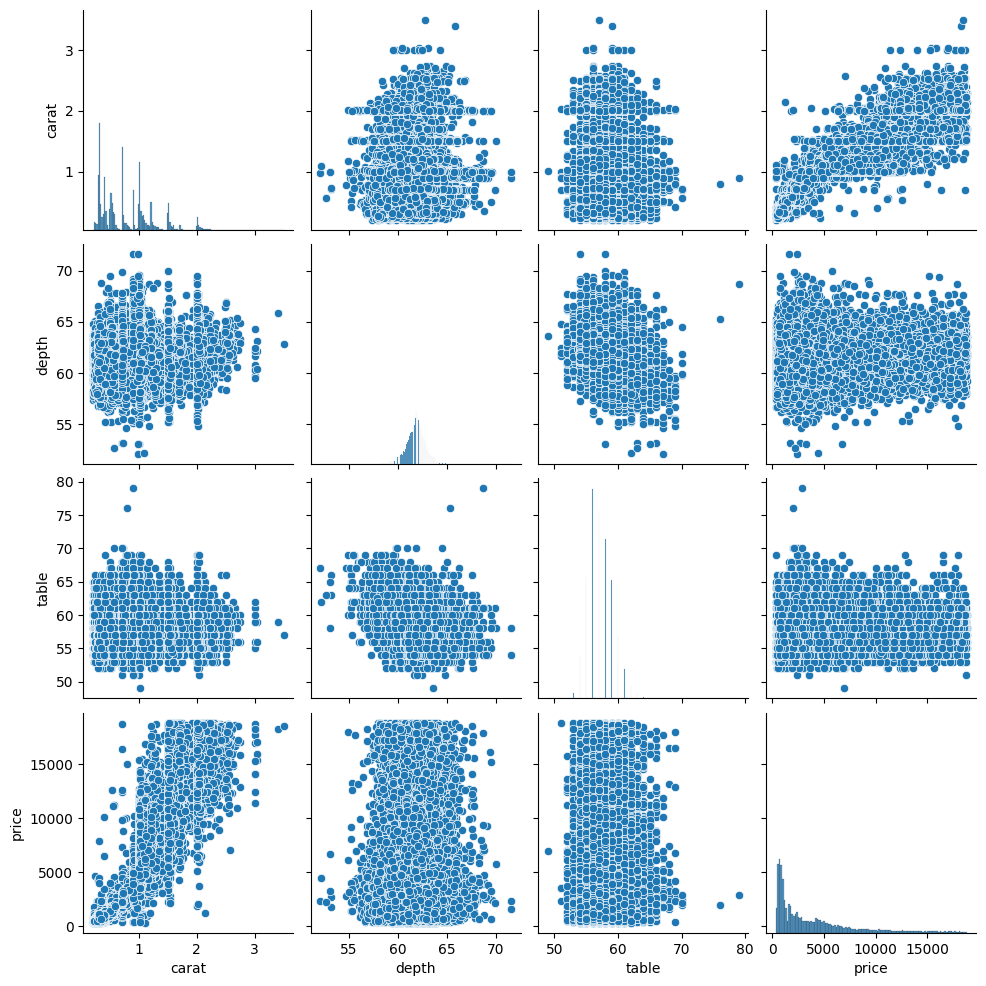

In [14]:
# Feature Relationships
sns.pairplot(diamond[['carat','depth','table','price']])

#### Exploratory Data Analysis reveals that carat is the strongest determinant of diamond price, showing a strong positive correlation. Diamond dimensions (x, y, z) also influence price since they relate to size. While cut, color, and clarity affect price, their impact is smaller compared to carat weight. The price distribution is highly skewed with a few extremely expensive diamonds, suggesting that transformation or robust models may be beneficial for prediction.

#### Identify target Feature(price)

In [36]:
X = diamond.drop("price", axis=1)
y = diamond["price"]

#### Train Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Identify Column Types


In [38]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

C:\Users\Ismat\AppData\Local\Temp\ipykernel_25544\882133644.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [40]:
# Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
]) 
# Define models
models = {

"LinearRegression": {
    "model": LinearRegression(),
    "params": {
        "model__fit_intercept":[True, False]
    }
},

"Ridge": {
    "model": Ridge(),
    "params": {
        "model__alpha":[0.01,0.1,1,10]
    }
},

"Lasso": {
    "model": Lasso(max_iter=5000),
    "params": {
        "model__alpha":[0.001,0.01,0.1,1]
    }
},

"KNN": {
    "model": KNeighborsRegressor(),
    "params": {
        "model__n_neighbors":[3,5,7,9],
        "model__weights":["uniform","distance"]
    }
},

"DecisionTree": {
    "model": DecisionTreeRegressor(random_state=42),
    "params": {
        "model__max_depth":[5,10,20,None],
        "model__min_samples_split":[2,5,10]
    }
},

"RandomForest": {
    "model": RandomForestRegressor(random_state=42),
    "params": {
        "model__n_estimators":[100,200],
        "model__max_depth":[10,20,None]
    }
},

"GradientBoosting": {
    "model": GradientBoostingRegressor(random_state=42),
    "params": {
        "model__n_estimators":[100,200],
        "model__learning_rate":[0.05,0.1]
    }
}

}

#### Loop training system

In [41]:
results = []

for name, config in models.items():

    print(f"\nTraining {name}")

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", config["model"])
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=config["params"],
        cv=3,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    preds = best_model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)

    print("Best Params:", grid.best_params_)
    print("R2:", r2)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse
    })


Training LinearRegression
Best Params: {'model__fit_intercept': True}
R2: 0.9447766976776784

Training Ridge
Best Params: {'model__alpha': 0.01}
R2: 0.9447767251285902

Training Lasso
Best Params: {'model__alpha': 0.1}
R2: 0.9447798894593245

Training KNN
Best Params: {'model__n_neighbors': 9, 'model__weights': 'distance'}
R2: 0.968558186753847

Training DecisionTree
Best Params: {'model__max_depth': 10, 'model__min_samples_split': 10}
R2: 0.9686671128993489

Training RandomForest
Best Params: {'model__max_depth': 20, 'model__n_estimators': 200}
R2: 0.976324666225765

Training GradientBoosting
Best Params: {'model__learning_rate': 0.1, 'model__n_estimators': 200}
R2: 0.9730171812888394


#### Convert results to a dataframe

In [42]:
results_df = pd.DataFrame(results)
results_df

,Model,Best Params,R2,MSE,RMSE
0,LinearRegression,{'model__fit_intercept': True},0.944777,892385.135301,944.661387
1,Ridge,{'model__alpha': 0.01},0.944777,892384.691706,944.661152
2,Lasso,{'model__alpha': 0.1},0.944780,892333.557464,944.634087
3,KNN,"{'model__n_neighbors': 9, 'model__weights': 'd...",0.968558,508086.361877,712.801769
4,DecisionTree,"{'model__max_depth': 10, 'model__min_samples_s...",0.968667,506326.161581,711.565992
5,RandomForest,"{'model__max_depth': 20, 'model__n_estimators'...",0.976325,382583.348784,618.533224
6,GradientBoosting,"{'model__learning_rate': 0.1, 'model__n_estima...",0.973017,436030.902060,660.326360


### Train ANN Model (Keras)

In [43]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [44]:
ann = Sequential()

ann.add(Dense(128, activation="relu", input_shape=(X_train_prep.shape[1],)))
ann.add(Dense(64, activation="relu"))
ann.add(Dense(32, activation="relu"))

ann.add(Dense(1))

ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

ann.fit(
    X_train_prep,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

d:\Diamond_ML_Project\di_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 2995378.2500 - mae: 813.1725 - val_loss: 535748.5000 - val_mae: 429.6472
Epoch 2/20
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 505655.1562 - mae: 378.0721 - val_loss: 434712.4688 - val_mae: 351.4375
Epoch 3/20
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 461308.4688 - mae: 348.6666 - val_loss: 441771.1875 - val_mae: 349.4456
Epoch 4/20
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 442968.9375 - mae: 342.2352 - val_loss: 420440.3438 - val_mae: 344.5562
Epoch 5/20
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 430355.3125 - mae: 337.7549 - val_loss: 403567.8438 - val_mae: 335.3152
Epoch 6/20
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 417686.8125 - mae: 333.0009 - val_loss: 395934.0625 - val_mae: 333.0038
Epoch 7/20
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 408132.6875 - mae: 329.4404 - val_loss: 396560.6250 - val_mae: 335.8463
Epoch 8/20
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss:

In [45]:
ann_preds = ann.predict(X_test_prep).flatten()

r2_ann = r2_score(y_test, ann_preds)
mse_ann = mean_squared_error(y_test, ann_preds)
rmse_ann = np.sqrt(mse_ann)

results_df.loc[len(results_df)] = {
    "Model": "ANN",
    "R2": r2_ann,
    "MSE": mse_ann,
    "RMSE": rmse_ann,
    "Best_Params": "ANN_default"
}

1210/1210 ━━━━━━━━━━━━━━━━━━━━ 1s 792us/step


#### Final Model Comparison

In [46]:
results_df.sort_values("R2", ascending=False)

,Model,Best Params,R2,MSE,RMSE
7,ANN,NaN,0.978227,351836.531250,593.158100
5,RandomForest,"{'model__max_depth': 20, 'model__n_estimators'...",0.976325,382583.348784,618.533224
6,GradientBoosting,"{'model__learning_rate': 0.1, 'model__n_estima...",0.973017,436030.902060,660.326360
4,DecisionTree,"{'model__max_depth': 10, 'model__min_samples_s...",0.968667,506326.161581,711.565992
3,KNN,"{'model__n_neighbors': 9, 'model__weights': 'd...",0.968558,508086.361877,712.801769
2,Lasso,{'model__alpha': 0.1},0.944780,892333.557464,944.634087
1,Ridge,{'model__alpha': 0.01},0.944777,892384.691706,944.661152
0,LinearRegression,{'model__fit_intercept': True},0.944777,892385.135301,944.661387


Multiple regression algorithms were trained using a unified preprocessing pipeline. Hyperparameter tuning was performed using GridSearchCV to identify optimal model configurations. Model performance was evaluated using R², MSE, and RMSE. A loop-based training framework was implemented to ensure scalability and reproducibility of experiments.

### Actual vs Predicted Price Plot

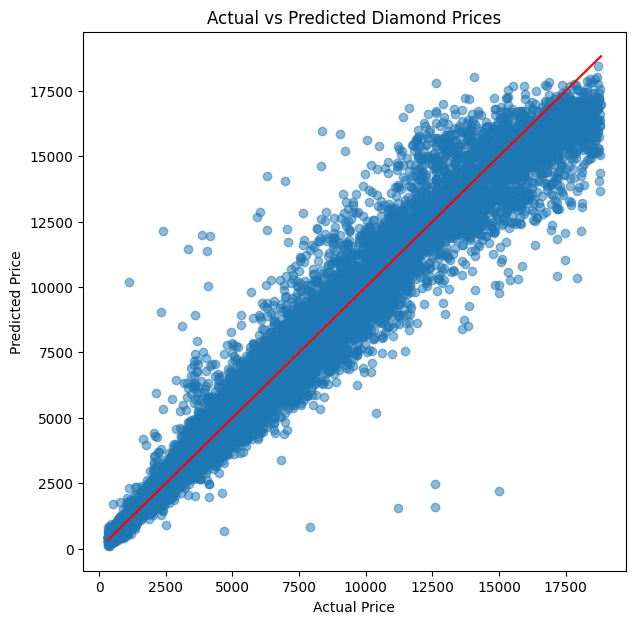

In [30]:
preds = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, preds, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Diamond Prices")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

Points close to the red diagonal line indicate accurate predictions. Most predictions cluster near the line, indicating the model captures the relationship between diamond characteristics and price effectively.

### Residual Analysis

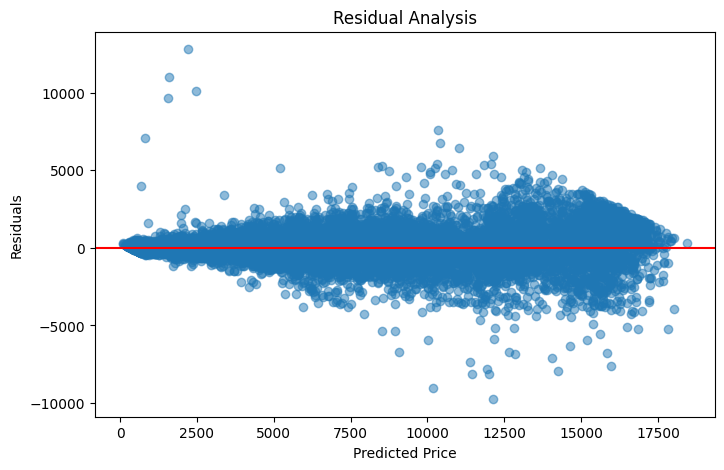

In [31]:
residuals = y_test - preds

plt.figure(figsize=(8,5))

plt.scatter(preds, residuals, alpha=0.5)

plt.axhline(0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Analysis")

plt.show()

Residuals are randomly distributed around zero, suggesting that the model captures most of the underlying structure in the data. No strong pattern in residuals indicates minimal systematic bias.

### Model Comparison Plot

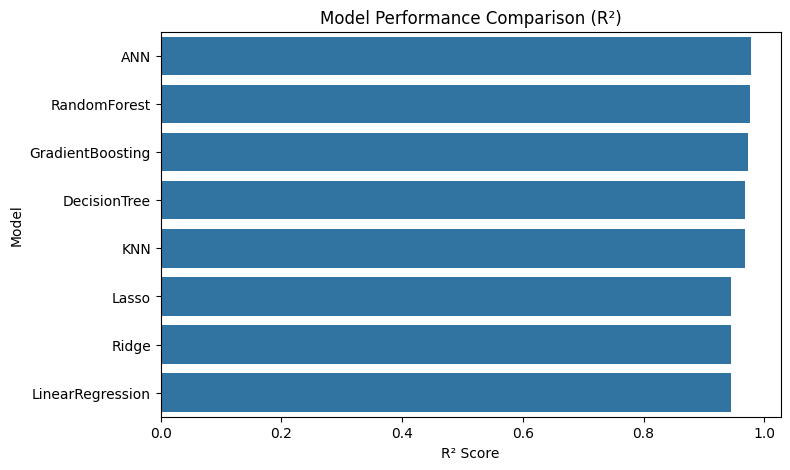

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort values (best model first)
results_df = results_df.sort_values(by="R2", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)

plt.title("Model Performance Comparison (R²)")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

Multiple regression algorithms were evaluated including Linear Regression, Ridge, Lasso, KNN, Decision Tree, Random Forest, Gradient Boosting, and an Artificial Neural Network.

ANN achieved the highest predictive performance with the largest R² score and lowest RMSE, demonstrating its ability to capture complex nonlinear relationships in diamond pricing.